In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# wfdb = WaveForm DataBase package to read MIT-BIH .dat/.hea/.atr files
!pip install wfdb -q

print("wfdb installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
wfdb installed successfully


In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc)
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [ ]:
# Path to your MIT-BIH folder on Drive
data_path = '/content/drive/MyDrive/Machine Learning/mit-bih-arrhythmia-database-1.0.0'

# MIT-BIH has 48 records — listing the standard ones
record_list = [
    '100', '101', '102', '103', '104', '105', '106', '107',
    '108', '109', '111', '112', '113', '114', '115', '116',
    '117', '118', '119', '121', '122', '123', '124', '200',
    '201', '202', '203', '205', '207', '208', '209', '210',
    '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

print(f"Total records available: {len(record_list)}")
print(f"Data path: {data_path}")

Total records available: 48
Data path: /content/drive/MyDrive/Machine Learning/mit-bih-arrhythmia-database-1.0.0


Record     : 100
Signal len : 650000 samples
Sampling Hz: 360 Hz
Duration   : 1805.6 seconds
Beat labels: {'+', 'V', 'N', 'A'}


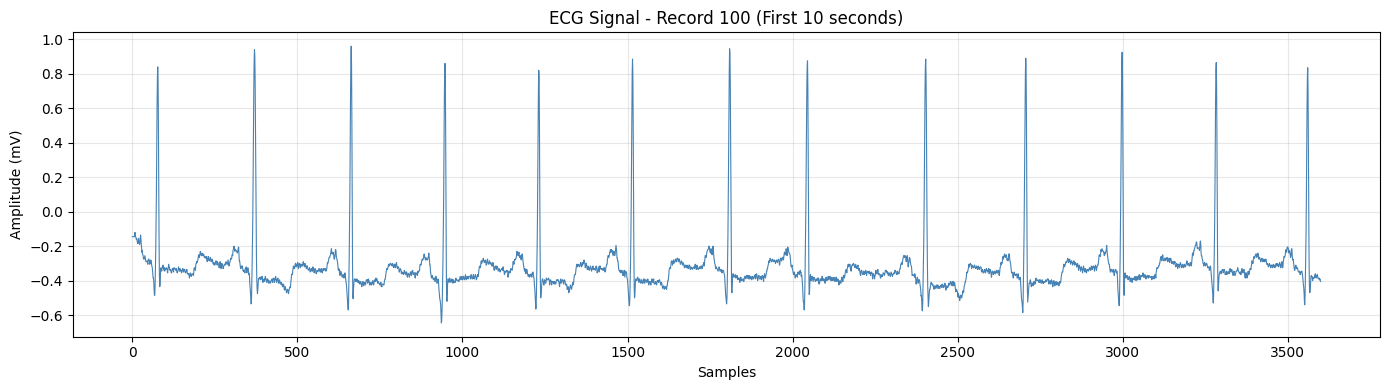

In [ ]:
# Read record 100 as a sample
record = wfdb.rdrecord(data_path + '/100')
annotation = wfdb.rdann(data_path + '/100', 'atr')

# ECG signal (Lead MLII = channel 0)
ecg_signal = record.p_signal[:, 0]
fs = record.fs  # Sampling frequency (360 Hz for MIT-BIH)

print(f"Record     : 100")
print(f"Signal len : {len(ecg_signal)} samples")
print(f"Sampling Hz: {fs} Hz")
print(f"Duration   : {len(ecg_signal)/fs:.1f} seconds")
print(f"Beat labels: {set(annotation.symbol)}")

# Plot first 10 seconds
plt.figure(figsize=(14, 4))
plt.plot(ecg_signal[:10*fs], color='steelblue', linewidth=0.8)
plt.title('ECG Signal - Record 100 (First 10 seconds)')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# MIT-BIH beat annotation symbols
print("=== BEAT ANNOTATION SYMBOLS ===")
print(f"All unique symbols in record 100: {set(annotation.symbol)}")

# Key symbols mapping
symbol_map = {
    'N': 'Normal',
    'L': 'Left bundle branch block',
    'R': 'Right bundle branch block',
    'A': 'Atrial premature beat',
    'V': 'Ventricular premature beat',
    '/': 'Paced beat',
    'f': 'Fusion of paced and normal',
    'F': 'Fusion of ventricular and normal',
    'Q': 'Unclassifiable beat',
    '!': 'Ventricular flutter wave',
    'E': 'Ventricular escape beat',
    'e': 'Atrial escape beat',
    'j': 'Nodal escape beat',
    'a': 'Aberrated atrial premature beat',
}

print("\nSymbol → Beat Type:")
for sym, label in symbol_map.items():
    print(f"  '{sym}' → {label}")

=== BEAT ANNOTATION SYMBOLS ===
All unique symbols in record 100: {'+', 'V', 'N', 'A'}

Symbol → Beat Type:
  'N' → Normal
  'L' → Left bundle branch block
  'R' → Right bundle branch block
  'A' → Atrial premature beat
  'V' → Ventricular premature beat
  '/' → Paced beat
  'f' → Fusion of paced and normal
  'F' → Fusion of ventricular and normal
  'Q' → Unclassifiable beat
  '!' → Ventricular flutter wave
  'E' → Ventricular escape beat
  'e' → Atrial escape beat
  'j' → Nodal escape beat
  'a' → Aberrated atrial premature beat


In [ ]:
def extract_features(ecg_signal, r_peak, fs=360, window=0.3):
    """
    Extract features from a single heartbeat window around R-peak.
    window = seconds on each side of the R-peak
    """
    half = int(window * fs)
    start = max(0, r_peak - half)
    end   = min(len(ecg_signal), r_peak + half)
    beat  = ecg_signal[start:end]

    if len(beat) < 10:
        return None

    features = {
        'mean'       : np.mean(beat),
        'std'        : np.std(beat),
        'max'        : np.max(beat),
        'min'        : np.min(beat),
        'range'      : np.max(beat) - np.min(beat),
        'rms'        : np.sqrt(np.mean(beat**2)),
        'skewness'   : pd.Series(beat).skew(),
        'kurtosis'   : pd.Series(beat).kurtosis(),
        'energy'     : np.sum(beat**2),
        'mean_abs'   : np.mean(np.abs(beat)),
        'zero_cross' : np.sum(np.diff(np.sign(beat)) != 0),
        'peak_amp'   : ecg_signal[r_peak],
    }
    return features

print("Feature extraction function defined!")
print("Features extracted per beat: mean, std, max, min, range, rms,")
print("                             skewness, kurtosis, energy, mean_abs,")
print("                             zero_crossings, peak_amplitude")

Feature extraction function defined!
Features extracted per beat: mean, std, max, min, range, rms,
                             skewness, kurtosis, energy, mean_abs,
                             zero_crossings, peak_amplitude


In [ ]:
# Use first 10 records to keep it manageable in Colab
# Increase this list for better accuracy
records_to_use = ['100', '101', '102', '103', '104',
                  '105', '106', '107', '108', '109']

all_features = []
all_labels   = []

# Normal beats vs Abnormal beats (binary classification)
normal_symbols   = ['N', 'L', 'R', 'e', 'j']       # Normal / near-normal
abnormal_symbols = ['A', 'V', 'F', 'f', '!', 'E', 'a']  # Abnormal

for rec_id in records_to_use:
    try:
        record     = wfdb.rdrecord(data_path + '/' + rec_id)
        annotation = wfdb.rdann(data_path + '/' + rec_id, 'atr')
        signal     = record.p_signal[:, 0]
        fs         = record.fs

        for idx, sym in zip(annotation.sample, annotation.symbol):
            if sym in normal_symbols:
                label = 0   # Normal
            elif sym in abnormal_symbols:
                label = 1   # Abnormal
            else:
                continue    # Skip unclear symbols

            feats = extract_features(signal, idx, fs)
            if feats:
                all_features.append(feats)
                all_labels.append(label)

        print(f"Record {rec_id} processed — {len(annotation.sample)} beats")

    except Exception as e:
        print(f" Record {rec_id} skipped: {e}")

print(f"\nTotal beats extracted : {len(all_labels)}")
print(f"   Normal  (label=0)     : {all_labels.count(0)}")
print(f"   Abnormal(label=1)     : {all_labels.count(1)}")

Record 100 processed — 2274 beats
Record 101 processed — 1874 beats
Record 102 processed — 2192 beats
Record 103 processed — 2091 beats
Record 104 processed — 2311 beats
Record 105 processed — 2691 beats
Record 106 processed — 2098 beats
Record 107 processed — 2140 beats
Record 108 processed — 1824 beats
Record 109 processed — 2535 beats

Total beats extracted : 16158
   Normal  (label=0)     : 14708
   Abnormal(label=1)     : 1450


In [ ]:
df = pd.DataFrame(all_features)
df['label'] = all_labels

print("=== FEATURE DATAFRAME ===")
print(df.head())
print(f"\nShape  : {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Drop any rows with NaN
df.dropna(inplace=True)
print(f"\nShape after dropna: {df.shape}")

=== FEATURE DATAFRAME ===
       mean       std   max    min  range       rms  skewness   kurtosis  \
0 -0.266405  0.192160  0.84 -0.485  1.325  0.328477  3.944164  17.628175   
1 -0.314329  0.216260  0.94 -0.535  1.475  0.381537  4.158435  18.950726   
2 -0.334792  0.197423  0.96 -0.570  1.530  0.388666  4.754532  25.105087   
3 -0.339838  0.186795  0.86 -0.645  1.505  0.387791  4.622010  24.326521   
4 -0.342454  0.176870  0.82 -0.565  1.385  0.385432  4.702921  25.090996   

      energy  mean_abs  zero_cross  peak_amp  label  
0  19.960975  0.311703           2     0.840      0  
1  31.443275  0.365949           2     0.940      0  
2  32.629275  0.376319           2     0.885      0  
3  32.482525  0.377569           2     0.810      0  
4  32.088450  0.376204           2     0.820      0  

Shape  : (16158, 13)

Missing values:
mean          0
std           0
max           0
min           0
range         0
rms           0
skewness      0
kurtosis      0
energy        0
mean_abs  

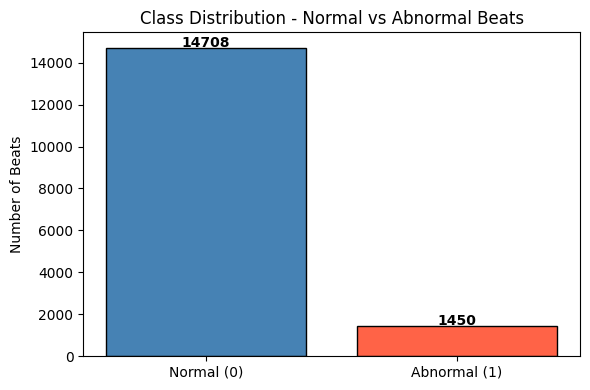

Classes found: [0, 1]
If only 1 class shows → increase records_to_use in Cell 8


In [ ]:
counts = df['label'].value_counts().sort_index()

colors = ['steelblue', 'tomato'][:len(counts)]  # only use as many colors as classes

plt.figure(figsize=(6, 4))
bars = plt.bar(range(len(counts)), counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(counts)),
           ['Normal (0)' if i == 0 else 'Abnormal (1)' for i in counts.index],
           rotation=0)
plt.title('Class Distribution - Normal vs Abnormal Beats')
plt.ylabel('Number of Beats')
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Classes found: {counts.index.tolist()}")
print(f"If only 1 class shows → increase records_to_use in Cell 8")

Normal beat index   : 77
Abnormal beat index : 2044
Symbols in record   : {'+', 'V', 'N', 'A'}


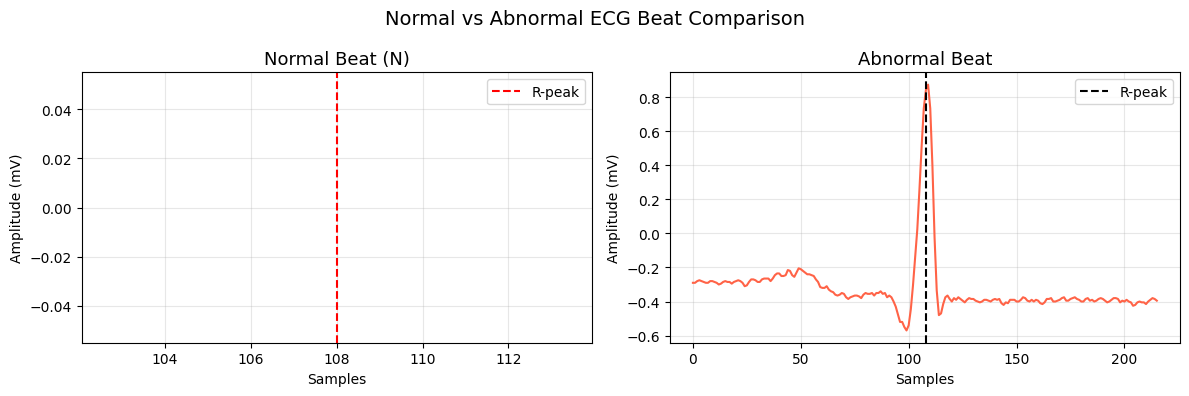

In [ ]:
# Redefine just in case scope was lost
normal_symbols   = ['N', 'L', 'R', 'e', 'j']
abnormal_symbols = ['A', 'V', 'F', 'f', '!', 'E', 'a']

record     = wfdb.rdrecord(data_path + '/100')
annotation = wfdb.rdann(data_path + '/100', 'atr')
signal     = record.p_signal[:, 0]
fs         = record.fs

normal_idx   = None
abnormal_idx = None

for idx, sym in zip(annotation.sample, annotation.symbol):
    if sym in normal_symbols and normal_idx is None:
        normal_idx = idx
    if sym in abnormal_symbols and abnormal_idx is None:
        abnormal_idx = idx
    if normal_idx and abnormal_idx:
        break

half = int(0.3 * fs)

# Safety check
print(f"Normal beat index   : {normal_idx}")
print(f"Abnormal beat index : {abnormal_idx}")
print(f"Symbols in record   : {set(annotation.symbol)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if normal_idx:
    axes[0].plot(signal[normal_idx-half : normal_idx+half],
                 color='steelblue', linewidth=1.5)
    axes[0].set_title('Normal Beat (N)', fontsize=13)
    axes[0].set_xlabel('Samples')
    axes[0].set_ylabel('Amplitude (mV)')
    axes[0].axvline(x=half, color='red', linestyle='--', label='R-peak')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No normal beat found',
                 ha='center', va='center', transform=axes[0].transAxes)

if abnormal_idx:
    axes[1].plot(signal[abnormal_idx-half : abnormal_idx+half],
                 color='tomato', linewidth=1.5)
    axes[1].set_title('Abnormal Beat', fontsize=13)
    axes[1].set_xlabel('Samples')
    axes[1].set_ylabel('Amplitude (mV)')
    axes[1].axvline(x=half, color='black', linestyle='--', label='R-peak')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No abnormal beat in record 100\n(try record 105 or 108)',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Normal vs Abnormal ECG Beat Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Prepare features and labels ───────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].values
y = df['label'].values

# ── Train / Test split (80 / 20, stratified so both classes appear) ────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Feature scaling ────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test     samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Class balance (train) — Normal: {(y_train==0).sum()}  Abnormal: {(y_train==1).sum()}")


Training samples : 12926
Test     samples : 3232
Features         : 12
Class balance (train) — Normal: 11766  Abnormal: 1160


In [ ]:
# ── Decision Tree Classifier ───────────────────────────────────────────────
# Using max_depth=5 to avoid over-fitting and keep the tree interpretable.
# criterion='entropy' → Information Gain (ID3 style) — matches your syllabus.
dt = DecisionTreeClassifier(
    criterion='entropy',   # Information Gain
    max_depth=5,           # Limit depth to avoid over-fitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)
print("Decision Tree trained!")
print(f"Tree depth (actual) : {dt.get_depth()}")
print(f"Number of leaves    : {dt.get_n_leaves()}")


Decision Tree trained!
Tree depth (actual) : 5
Number of leaves    : 28


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97      2942
    Abnormal       0.81      0.38      0.51       290

    accuracy                           0.94      3232
   macro avg       0.88      0.68      0.74      3232
weighted avg       0.93      0.94      0.93      3232



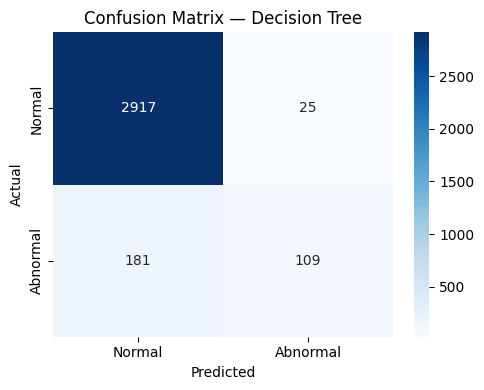

True  Negatives (Normal   correctly predicted): 2917
False Positives (Normal   wrongly as Abnormal): 25
False Negatives (Abnormal wrongly as Normal  ): 181
True  Positives (Abnormal correctly predicted): 109


In [ ]:
# ── Predictions ────────────────────────────────────────────────────────────
y_pred      = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)[:, 1]   # probability of Abnormal class

# ── Classification Report ──────────────────────────────────────────────────
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

# ── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix — Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (Normal   correctly predicted): {tn}")
print(f"False Positives (Normal   wrongly as Abnormal): {fp}")
print(f"False Negatives (Abnormal wrongly as Normal  ): {fn}")
print(f"True  Positives (Abnormal correctly predicted): {tp}")


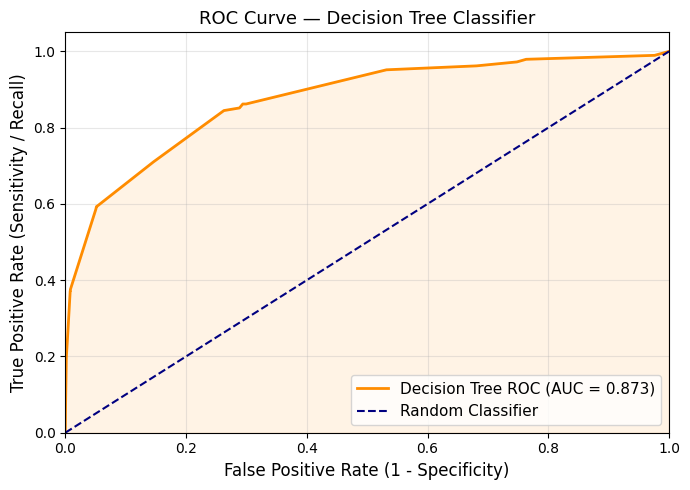

AUC Score : 0.8730
AUC = 1.0 → perfect classifier
AUC = 0.5 → no better than random guessing


In [ ]:
# ── ROC Curve and AUC ──────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Decision Tree ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Decision Tree Classifier', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score : {roc_auc:.4f}")
print("AUC = 1.0 → perfect classifier")
print("AUC = 0.5 → no better than random guessing")


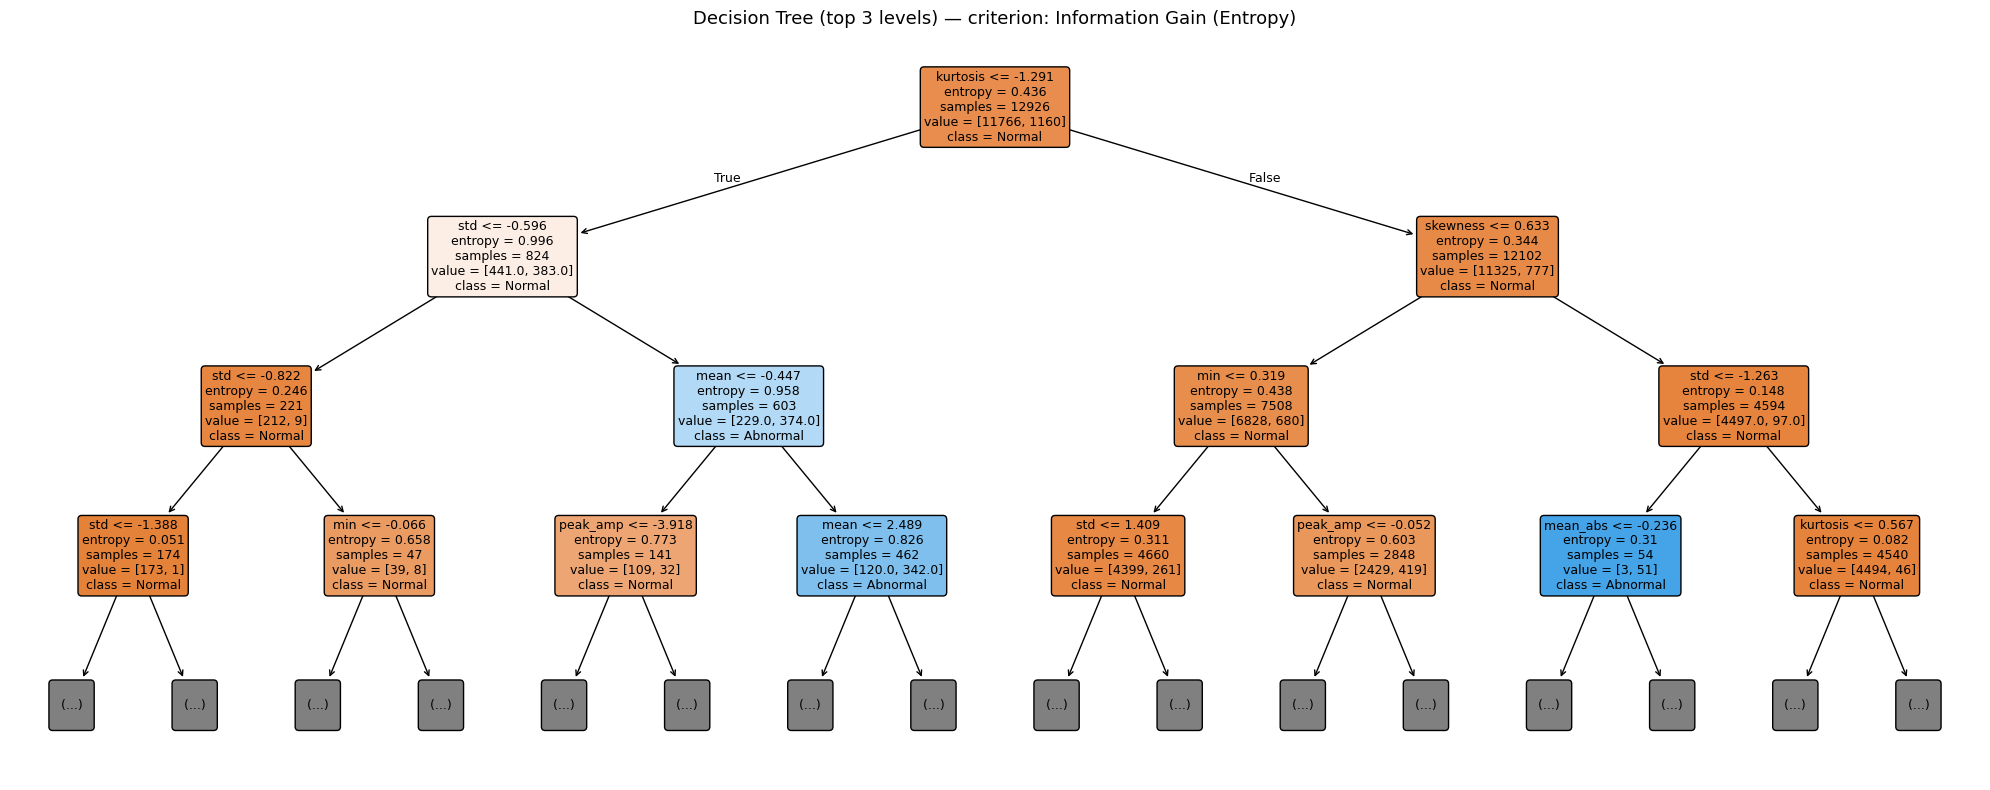

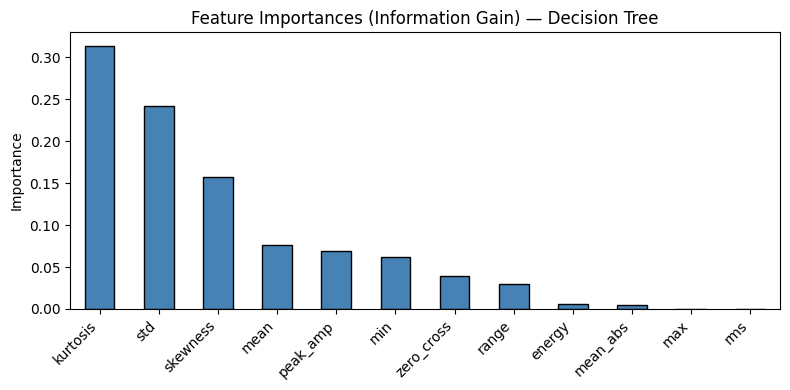

Top 3 most important features:
  kurtosis        : 0.3142
  std             : 0.2418
  skewness        : 0.1569


In [ ]:
# ── Visualise the Decision Tree (top 3 levels) ─────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,                    # show only top 3 levels for readability
    feature_names=feature_cols,
    class_names=['Normal', 'Abnormal'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (top 3 levels) — criterion: Information Gain (Entropy)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Feature Importances ────────────────────────────────────────────────────
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances (Information Gain) — Decision Tree', fontsize=12)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in importances.head(3).items():
    print(f"  {feat:15s} : {imp:.4f}")
